# ELEC/PHYS 450/550 — Programming Assignment 1
# Basic Quantum Circuits and Single-Qubit Operations

**Spring 2026 — Dr. Mehmet Cengiz Onbaşlı**

---

### Instructions

- Complete **all 5 questions** below by filling in the code cells marked with `### YOUR CODE HERE ###`.
- Do **not** modify any cells that say *"DO NOT MODIFY"*.
- After completing every question, **restart the kernel and run all cells** to make sure everything executes without errors.
- **Deliverables:** Submit (1) this completed `.ipynb` file **and** (2) an exported PDF via KUHUB Learn by the deadline.

### Honor Code

*I hereby certify that I have completed this assignment on my own without any help from anyone else. I have not used, accessed, received, or distributed any information from/to any other unauthorized source in completing this assignment. The effort in this assignment belongs only to me.*

**Student Name:** Ahmet Buğra Ertürk  
**Student ID:** 0086877

---
## Setup — DO NOT MODIFY

Run the cell below to import the libraries you will need throughout this assignment.

In [1]:
# ============================================================
# DO NOT MODIFY THIS CELL
# ============================================================
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector

print("Setup complete.")

Setup complete.


---
## Question 1 — Quantum States and Superposition (20 pts)

In this question you will create fundamental single-qubit quantum states and verify their measurement probabilities.

### Q1 Tasks

1. **|0⟩ state:** Create a `QuantumCircuit` with 1 qubit (the qubit initializes in |0⟩ by default). Obtain the `Statevector` from the circuit and store it in `sv_zero`.

2. **|1⟩ state:** Create a new `QuantumCircuit` with 1 qubit, apply a **Pauli-X** gate to flip it to |1⟩. Obtain the `Statevector` and store it in `sv_one`.

3. **|+⟩ state:** Create a new `QuantumCircuit` with 1 qubit, apply a **Hadamard** gate to put it into the equal superposition state |+⟩ = (|0⟩ + |1⟩)/√2. Obtain the `Statevector` and store it in `sv_plus`.

4. **|−⟩ state:** Create a new `QuantumCircuit` with 1 qubit. Using a combination of **Pauli-X** and **Hadamard** gates, prepare the state |−⟩ = (|0⟩ − |1⟩)/√2. Obtain the `Statevector` and store it in `sv_minus`.

5. **Measurement probabilities:** For each of the four states, use the `.probabilities()` method to compute the measurement probabilities in the computational basis. Store the results in `prob_zero`, `prob_one`, `prob_plus`, and `prob_minus` respectively. Print all four probability arrays.

*Hint: `Statevector.from_instruction(circuit)` returns the statevector of a circuit.*

In [2]:
# ----------------------------------------------------------
# Q1.1  |0⟩ state
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc = QuantumCircuit(1)
sv_zero = Statevector.from_instruction(qc)

# ----------------------------------------------------------
# Q1.2  |1⟩ state  (use Pauli-X)
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc = QuantumCircuit(1)
qc.x(0)
sv_one = Statevector.from_instruction(qc)

# ----------------------------------------------------------
# Q1.3  |+⟩ state  (use Hadamard)
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc = QuantumCircuit(1)
qc.h(0)
sv_plus = Statevector.from_instruction(qc)

# ----------------------------------------------------------
# Q1.4  |−⟩ state  (use Pauli-X then Hadamard)
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
sv_minus = Statevector.from_instruction(qc)

In [3]:
# ----------------------------------------------------------
# Q1.5  Compute and print measurement probabilities
# ----------------------------------------------------------

### YOUR CODE HERE ###
prob_zero = sv_zero.probabilities()
prob_one = sv_one.probabilities()
prob_plus = sv_plus.probabilities()
prob_minus = sv_minus.probabilities()

In [4]:
# ============================================================
# AUTO-CHECK — DO NOT MODIFY
# ============================================================
assert np.allclose(sv_zero.data, [1, 0]), "sv_zero is incorrect"
assert np.allclose(sv_one.data, [0, 1]), "sv_one is incorrect"
assert np.allclose(sv_plus.data, [1/np.sqrt(2), 1/np.sqrt(2)]), "sv_plus is incorrect"
assert np.allclose(sv_minus.data, [1/np.sqrt(2), -1/np.sqrt(2)]), "sv_minus is incorrect"

assert np.allclose(prob_zero, [1.0, 0.0]), "prob_zero is incorrect"
assert np.allclose(prob_one, [0.0, 1.0]), "prob_one is incorrect"
assert np.allclose(prob_plus, [0.5, 0.5]), "prob_plus is incorrect"
assert np.allclose(prob_minus, [0.5, 0.5]), "prob_minus is incorrect"

print("All Q1 checks passed!")

All Q1 checks passed!


---
## Question 2 — Single-Qubit Gates: Pauli and Hadamard (20 pts)

In this question you will explore the matrix representations and algebraic properties of fundamental single-qubit gates.

### Q2 Tasks

1. **Gate matrices:** Using `Operator(gate)` where `gate` is a Qiskit gate object (e.g., `from qiskit.circuit.library import XGate, YGate, ZGate, HGate`), extract the **unitary matrix** (as a NumPy array) for each of the following gates and store them in the indicated variables:
   - Pauli-X → `mat_X`
   - Pauli-Y → `mat_Y`
   - Pauli-Z → `mat_Z`
   - Hadamard → `mat_H`
   
   Print all four matrices.

2. **Involutory property:** Verify numerically that each Pauli gate is its own inverse, i.e., X² = Y² = Z² = I. Compute `mat_X @ mat_X`, `mat_Y @ mat_Y`, and `mat_Z @ mat_Z` and confirm they are (approximately) equal to the 2×2 identity matrix. Store the three results in `XX`, `YY`, `ZZ`.

3. **Hadamard self-inverse:** Verify that H² = I by computing `mat_H @ mat_H`. Store the result in `HH`.

4. **Pauli product relation:** Verify the identity XZ = −iY by computing `mat_X @ mat_Z` and comparing it with `−1j * mat_Y`. Store the product in `XZ_product` and print whether the relation holds (True/False).

*Hint: Use `np.allclose()` for numerical comparisons.*

In [5]:
from qiskit.circuit.library import XGate, YGate, ZGate, HGate

# ----------------------------------------------------------
# Q2.1  Extract unitary matrices
# ----------------------------------------------------------

### YOUR CODE HERE ###
mat_X = Operator(XGate()).data
mat_Y = Operator(YGate()).data
mat_Z = Operator(ZGate()).data
mat_H = Operator(HGate()).data

In [6]:
# ----------------------------------------------------------
# Q2.2  Verify Pauli involutory property (X²=Y²=Z²=I)
# ----------------------------------------------------------

### YOUR CODE HERE ###
XX = mat_X @ mat_X
YY = mat_Y @ mat_Y
ZZ = mat_Z @ mat_Z
np.allclose(XX, YY, ZZ, np.eye(2))

True

In [7]:
# ----------------------------------------------------------
# Q2.3  Verify H² = I
# ----------------------------------------------------------

### YOUR CODE HERE ###
HH = mat_H @ mat_H
np.allclose(HH, np.eye(2))

True

In [8]:
# ----------------------------------------------------------
# Q2.4  Verify XZ = -iY
# ----------------------------------------------------------

### YOUR CODE HERE ###
XZ_product = mat_X @ mat_Z
IY = -1j * mat_Y
np.allclose(XZ_product, IY)

True

In [9]:
# ============================================================
# AUTO-CHECK — DO NOT MODIFY
# ============================================================
I2 = np.eye(2)
assert np.allclose(XX, I2), "X² ≠ I"
assert np.allclose(YY, I2), "Y² ≠ I"
assert np.allclose(ZZ, I2), "Z² ≠ I"
assert np.allclose(HH, I2), "H² ≠ I"
assert np.allclose(XZ_product, -1j * mat_Y), "XZ ≠ -iY"

print("All Q2 checks passed!")

All Q2 checks passed!


---
## Question 3 — Two-Qubit Gates and Bell State Creation (20 pts)

Bell states are maximally entangled two-qubit states that form an orthonormal basis for the two-qubit Hilbert space. In this question you will construct all four Bell states.

### Background

The four Bell states are:

| Bell State | Formula |
|:---:|:---|
| |Φ⁺⟩ | (|00⟩ + |11⟩) / √2 |
| |Φ⁻⟩ | (|00⟩ − |11⟩) / √2 |
| |Ψ⁺⟩ | (|01⟩ + |10⟩) / √2 |
| |Ψ⁻⟩ | (|01⟩ − |10⟩) / √2 |

### Q3 Tasks

For each Bell state, create a `QuantumCircuit` with **2 qubits** and use a combination of **Hadamard (H)**, **Pauli-X**, **Pauli-Z**, and **CNOT (CX)** gates to prepare the state. Extract the `Statevector` and store each one as indicated below.

1. **|Φ⁺⟩:** Apply H on qubit 0, then CNOT with control=0 and target=1. Store statevector in `bell_phi_plus`.

2. **|Φ⁻⟩:** Modify the |Φ⁺⟩ circuit so that the resulting state has a relative minus sign between the |00⟩ and |11⟩ terms. Store statevector in `bell_phi_minus`.

3. **|Ψ⁺⟩:** Construct a circuit that produces (|01⟩ + |10⟩)/√2. Store statevector in `bell_psi_plus`.

4. **|Ψ⁻⟩:** Construct a circuit that produces (|01⟩ − |10⟩)/√2. Store statevector in `bell_psi_minus`.

5. **Draw all four circuits** using `circuit.draw('mpl')` and display them.

*Hint: The standard Bell circuit is H on qubit 0 followed by CNOT(0,1). Additional single-qubit gates before or after can produce the other three Bell states. Pay attention to Qiskit's qubit ordering convention (little-endian).*

In [10]:
# ----------------------------------------------------------
# Q3.1  |Φ⁺⟩ = (|00⟩ + |11⟩) / √2
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc1 = QuantumCircuit(2)
qc1.h(0)
qc1.cx(0,1)
bell_phi_plus = Statevector.from_instruction(qc1)

In [11]:
# ----------------------------------------------------------
# Q3.2  |Φ⁻⟩ = (|00⟩ − |11⟩) / √2
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc2 = qc1.copy()
qc2.z(0)
bell_phi_minus = Statevector.from_instruction(qc2)

In [12]:
# ----------------------------------------------------------
# Q3.3  |Ψ⁺⟩ = (|01⟩ + |10⟩) / √2
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc3 = QuantumCircuit(2)
qc3.h(0)
qc3.cx(0,1)
qc3.x(1)
bell_psi_plus = Statevector.from_instruction(qc3)

In [13]:
# ----------------------------------------------------------
# Q3.4  |Ψ⁻⟩ = (|01⟩ − |10⟩) / √2
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc4 = QuantumCircuit(2)
qc4.h(0)
qc4.z(0)
qc4.cx(0,1)
qc4.x(1)
bell_psi_minus = Statevector.from_instruction(qc4)

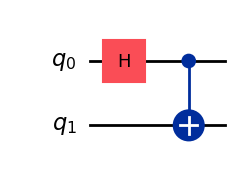

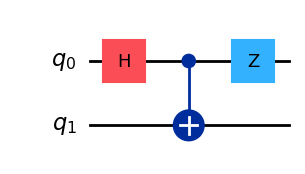

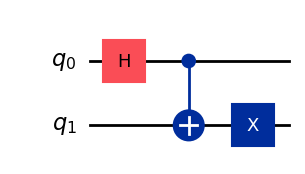

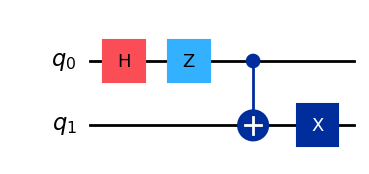

In [14]:
# ----------------------------------------------------------
# Q3.5  Draw all four Bell state circuits
# ----------------------------------------------------------

### YOUR CODE HERE ###
display(qc1.draw('mpl'))
display(qc2.draw('mpl'))
display(qc3.draw('mpl'))
display(qc4.draw('mpl'))

In [15]:
# ============================================================
# AUTO-CHECK — DO NOT MODIFY
# ============================================================
# Qiskit uses little-endian ordering: |q1 q0⟩
# So |00⟩=index0, |01⟩=index1, |10⟩=index2, |11⟩=index3

s = 1 / np.sqrt(2)
expected_phi_plus  = np.array([s, 0, 0, s])    # (|00⟩ + |11⟩)/√2
expected_phi_minus = np.array([s, 0, 0, -s])   # (|00⟩ - |11⟩)/√2
expected_psi_plus  = np.array([0, s, s, 0])    # (|01⟩ + |10⟩)/√2
expected_psi_minus = np.array([0, s, -s, 0])   # (|01⟩ - |10⟩)/√2

# Allow for a global phase difference
def states_equal(sv, expected):
    """Check if two statevectors are equal up to global phase."""
    data = np.array(sv.data)
    # Find first non-zero element to determine phase
    for i in range(len(data)):
        if abs(expected[i]) > 1e-10:
            phase = data[i] / expected[i]
            return np.allclose(data, phase * expected)
    return False

assert states_equal(bell_phi_plus, expected_phi_plus), "|Φ⁺⟩ is incorrect"
assert states_equal(bell_phi_minus, expected_phi_minus), "|Φ⁻⟩ is incorrect"
assert states_equal(bell_psi_plus, expected_psi_plus), "|Ψ⁺⟩ is incorrect"
assert states_equal(bell_psi_minus, expected_psi_minus), "|Ψ⁻⟩ is incorrect"

print("All Q3 checks passed!")

All Q3 checks passed!


---
## Question 4 — Entanglement Measure (20 pts)

A key concept in quantum computing is **entanglement**. One way to quantify entanglement in a pure two-qubit state is through the **concurrence** or, equivalently, the **entropy of entanglement** of the reduced density matrix.

### Background

For a two-qubit pure state |ψ⟩, the **reduced density matrix** of qubit 0 is obtained by tracing out qubit 1:

$$\rho_0 = \text{Tr}_1(|\psi\rangle\langle\psi|)$$

The **von Neumann entropy** of this reduced state quantifies entanglement:

$$S(\rho_0) = -\text{Tr}(\rho_0 \log_2 \rho_0) = -\sum_i \lambda_i \log_2 \lambda_i$$

where λᵢ are the eigenvalues of ρ₀. For a separable (product) state, S = 0. For a maximally entangled state (Bell state), S = 1.

### Q4 Tasks

1. **Write a function** `entanglement_entropy(qc)` that takes a `QuantumCircuit` with 2 qubits and returns the von Neumann entanglement entropy (a float). Steps inside the function:
   - Obtain the `Statevector` from the circuit.
   - Compute the **reduced density matrix** of qubit 0 using `statevector.partial_trace([1])` (trace out qubit 1).
   - Extract the eigenvalues of the reduced density matrix using `np.linalg.eigvalsh(rho.data)`.
   - Compute the von Neumann entropy: S = −Σ λᵢ log₂(λᵢ) for λᵢ > 0 (skip zero eigenvalues to avoid log(0)).

2. **Test your function** on the following circuits and store the entropy values:
   - `ent_product`: A circuit with NO entanglement (e.g., just apply X to qubit 0, identity on qubit 1). Expected entropy ≈ 0.
   - `ent_bell`: The |Φ⁺⟩ Bell state circuit from Q3. Expected entropy ≈ 1.0.
   - `ent_partial`: A partially entangled state — apply `RY(π/4)` on qubit 0 (using `qc.ry(np.pi/4, 0)`), then CNOT(0,1). Compute and store its entropy.

3. **Print** all three entropy values with descriptive labels.

In [16]:
# ----------------------------------------------------------
# Q4.1  Define the entanglement_entropy function
# ----------------------------------------------------------

from qiskit.quantum_info import partial_trace, concurrence, entropy
import math

def entanglement_entropy(qc):
    """
    Compute the von Neumann entanglement entropy for a 2-qubit circuit.
    
    Parameters:
        qc (QuantumCircuit): A 2-qubit quantum circuit.
    
    Returns:
        float: The entanglement entropy S(ρ_0).
    """
    ### YOUR CODE HERE ###
    statevector = Statevector.from_circuit(qc)
    rdm = partial_trace(statevector, [1])
    eigvals = np.linalg.eigvalsh(rdm.data)
    s = 0
    for i in eigvals:
        if i>0:
            s -= i*math.log(i,2)
    return s

In [17]:
# ----------------------------------------------------------
# Q4.2  Test on product state, Bell state, and partial entanglement
# ----------------------------------------------------------

### YOUR CODE HERE ###

qc = QuantumCircuit(2)
qc.x(0)
qc.id(1)
ent_product = entanglement_entropy(qc)   # should be ≈ 0
ent_bell    = entanglement_entropy(qc3)   # should be ≈ 1
qc = QuantumCircuit(2)
qc.ry(np.pi/4, 0)
qc.cx(0, 1)
ent_partial = entanglement_entropy(qc)   # should be between 0 and 1


In [18]:
# ----------------------------------------------------------
# Q4.3  Print the results
# ----------------------------------------------------------

### YOUR CODE HERE ###
print("ent_product: ", ent_product)
print("ent_bell: ", ent_bell)
print("ent_partial: ", ent_partial)

ent_product:  0.0
ent_bell:  1.0
ent_partial:  0.6008760366928562


In [19]:
# ============================================================
# AUTO-CHECK — DO NOT MODIFY
# ============================================================
assert abs(ent_product - 0.0) < 0.01, f"Product state entropy should be ≈0, got {ent_product}"
assert abs(ent_bell - 1.0) < 0.01, f"Bell state entropy should be ≈1, got {ent_bell}"
assert 0.0 < ent_partial < 1.0, f"Partial entanglement entropy should be between 0 and 1, got {ent_partial}"

print("All Q4 checks passed!")

All Q4 checks passed!


---
## Question 5 — Measurement Probability Analysis (20 pts)

In this question you will build a multi-gate circuit, predict its measurement outcomes analytically, and verify your predictions by simulation.

### Q5 Tasks

1. **Build the circuit:** Create a `QuantumCircuit` with **2 qubits and 2 classical bits**. Apply the following gates in order:
   - Hadamard on qubit 0
   - Pauli-Z on qubit 0
   - CNOT with control = qubit 0, target = qubit 1
   - Hadamard on qubit 1
   - Measure both qubits into the classical bits
   
   Store the circuit in `qc5` and draw it.

2. **Statevector before measurement:** Create the **same circuit without measurement gates** (no `measure`). Obtain the `Statevector` and store it in `sv_pre_meas`. Print the statevector using `print(sv_pre_meas)` or `sv_pre_meas.draw('latex')` to inspect the amplitudes.

3. **Theoretical probabilities:** Based on the statevector amplitudes you obtained, manually compute the probability of each computational basis outcome: P(|00⟩), P(|01⟩), P(|10⟩), P(|11⟩). Store them in a dictionary `theory_probs` with string keys: `{'00': ..., '01': ..., '10': ..., '11': ...}`. Remember: probability = |amplitude|².

4. **Simulated counts:** Use the `Statevector` to sample 10000 measurement outcomes. You can do this with:
   ```python
   counts = sv_pre_meas.sample_counts(10000)
   ```
   Store the counts dictionary in `sim_counts` and display it using `plot_histogram(sim_counts)`.

5. **Comparison:** Print `theory_probs` and the **normalized** simulated probabilities (counts / 10000) side by side and briefly comment (in a print statement or markdown cell) on whether they agree.

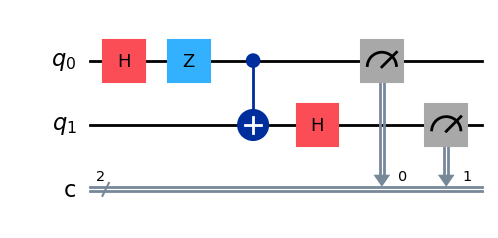

In [20]:
# ----------------------------------------------------------
# Q5.1  Build and draw the circuit (with measurements)
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc5 = QuantumCircuit(2, 2)
qc5.h(0)
qc5.z(0)
qc5.cx(0, 1)
qc5.h(1)
qc5.measure([0, 1], [0, 1])
qc5.draw('mpl')

In [21]:
# ----------------------------------------------------------
# Q5.2  Statevector before measurement (circuit without measure)
# ----------------------------------------------------------

### YOUR CODE HERE ###
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.z(0)
qc.cx(0, 1)
qc.h(1)
sv_pre_meas = Statevector.from_instruction(qc)
print(sv_pre_meas)

Statevector([ 0.5+0.j, -0.5+0.j,  0.5+0.j,  0.5+0.j],
            dims=(2, 2))


In [22]:
# ----------------------------------------------------------
# Q5.3  Theoretical probabilities
# ----------------------------------------------------------

### YOUR CODE HERE ###

theory_probs = {'00': sv_pre_meas[0]**2, '01': sv_pre_meas[1]**2, '10': sv_pre_meas[2]**2, '11': sv_pre_meas[3]**2}


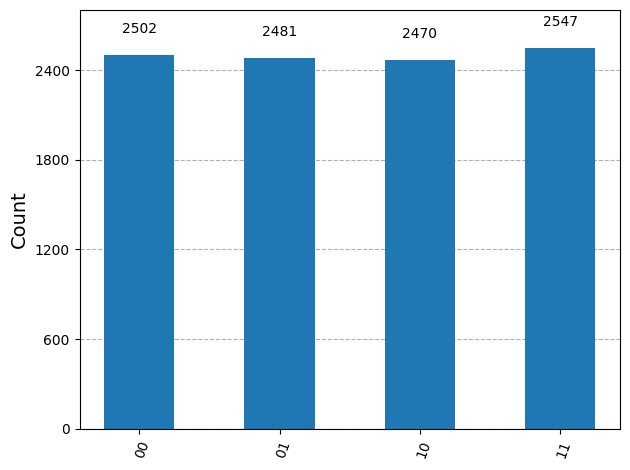

In [23]:
# ----------------------------------------------------------
# Q5.4  Simulated counts (10000 shots)
# ----------------------------------------------------------

### YOUR CODE HERE ###
sim_counts = sv_pre_meas.sample_counts(10000)
plot_histogram(sim_counts)

In [24]:
# ----------------------------------------------------------
# Q5.5  Compare theoretical and simulated probabilities
# ----------------------------------------------------------

### YOUR CODE HERE ###
print(f"Theoretical probabilities: |00>: {theory_probs['00'].real:.4f}, |01>: {theory_probs['01'].real:.4f}, |10>: {theory_probs['10'].real:.4f}, |11>: {theory_probs['11'].real:.4f}")
print(f"Simulated probabilities: |00>: {sim_counts['00']/10000}, |01>: {sim_counts['01']/10000}, |10>: {sim_counts['10']/10000}, |11>: {sim_counts['11']/10000}")
print(f"\n{'='*120}\n")
print("Theoretical probs are calculated using linear algebra, but simulated ones use shots and it caused a noise.")
print(f"\n{'='*120}")

Theoretical probabilities: |00>: 0.2500, |01>: 0.2500, |10>: 0.2500, |11>: 0.2500
Simulated probabilities: |00>: 0.2502, |01>: 0.2481, |10>: 0.247, |11>: 0.2547


Theoretical probs are calculated using linear algebra, but simulated ones use shots and it caused a noise.



In [25]:
# ============================================================
# AUTO-CHECK — DO NOT MODIFY
# ============================================================
assert isinstance(theory_probs, dict), "theory_probs must be a dictionary"
assert set(theory_probs.keys()) == {'00', '01', '10', '11'}, "theory_probs must have keys '00','01','10','11'"
assert abs(sum(theory_probs.values()) - 1.0) < 1e-6, "Probabilities must sum to 1"

# Verify against actual statevector probabilities
sv_probs = sv_pre_meas.probabilities()
for i, key in enumerate(['00', '01', '10', '11']):
    assert abs(theory_probs[key] - sv_probs[i]) < 0.01, f"theory_probs['{key}'] does not match statevector"

# Verify simulation ran with enough shots
assert isinstance(sim_counts, dict), "sim_counts must be a dictionary"
total_shots = sum(sim_counts.values())
assert total_shots == 10000, f"Expected 10000 shots, got {total_shots}"

print("All Q5 checks passed!")

All Q5 checks passed!


---
## Submission Checklist

Before submitting, verify the following:

- [ ] All 5 questions are completed.
- [ ] All auto-check cells print "passed" with no assertion errors.
- [ ] The notebook runs from top to bottom without errors (Kernel → Restart & Run All).
- [ ] Your name and student ID are filled in at the top.
- [ ] You have exported the notebook as a PDF.
- [ ] You are submitting both the `.ipynb` file and the `.pdf` file on KUHUB Learn.

**Good luck!**